# Preparation of the data

In [157]:
import pandas as pd
dka_patients = pd.read_csv('../dp_cgans/resources/icu_dka_dataset.csv') # no preprocessing
# dka_patients = dka_patients.drop('subject_id', axis=1)
# dka_patients = pd.read_csv('imputed_dataset_0.5.csv')
# dataset_paper =  dka_patients[['apsiii', 'lactate_max', 'age', 'sofa', 'urineoutput', 'creatinine_max', 'wbc_max', 'bun_max', 'calcium_max', 'chloride_max', 'los', 'ph_max', 'mbp_max', 'weight', 'hemoglobin_min', 'platelet_min', 'osmolality_min', 'sodium_max', 'potassium_max', 'calcium_min', 'osmolality_max', 'resp_rate_max', 'glucose_max', 'heart_rate_max', 'ph_min', 'vasopressor', 'cardiac_disease', 'osmolality_initial', 'in_hospital_death']]
# min/max, the ratio of the minimum and maximum plasma osmolality; ‘I’_max, maximum body temperature; map_min


In [132]:
dataset_paper.info()
X, y, X_encoded, y_aligned = get_clean_data(dataset_paper)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1571 entries, 0 to 1570
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   apsiii              1571 non-null   int64  
 1   lactate_max         1571 non-null   float64
 2   age                 1571 non-null   int64  
 3   sofa                1571 non-null   int64  
 4   urineoutput         1571 non-null   float64
 5   creatinine_max      1571 non-null   float64
 6   wbc_max             1571 non-null   float64
 7   bun_max             1571 non-null   float64
 8   calcium_max         1571 non-null   float64
 9   chloride_max        1571 non-null   float64
 10  los                 1571 non-null   float64
 11  ph_max              1571 non-null   float64
 12  mbp_max             1571 non-null   float64
 13  weight              1571 non-null   float64
 14  hemoglobin_min      1571 non-null   float64
 15  platelet_min        1571 non-null   float64
 16  osmola

In [74]:
def get_clean_data(dataset):
    # Prepare data
    X = dataset.drop('in_hospital_death', axis=1)  # Exclude outcome
    y = dataset['in_hospital_death']

    X_encoded = pd.get_dummies(X, drop_first=True)

    X_encoded = X_encoded.dropna()
    X_encoded = X_encoded.astype(float)
    y_aligned = y.loc[X_encoded.index]

    return X, y, X_encoded, y_aligned

In [158]:
X, y, X_encoded, y_aligned = get_clean_data(dka_patients)

In [133]:
X_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1571 entries, 0 to 1570
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   apsiii              1571 non-null   float64
 1   lactate_max         1571 non-null   float64
 2   age                 1571 non-null   float64
 3   sofa                1571 non-null   float64
 4   urineoutput         1571 non-null   float64
 5   creatinine_max      1571 non-null   float64
 6   wbc_max             1571 non-null   float64
 7   bun_max             1571 non-null   float64
 8   calcium_max         1571 non-null   float64
 9   chloride_max        1571 non-null   float64
 10  los                 1571 non-null   float64
 11  ph_max              1571 non-null   float64
 12  mbp_max             1571 non-null   float64
 13  weight              1571 non-null   float64
 14  hemoglobin_min      1571 non-null   float64
 15  platelet_min        1571 non-null   float64
 16  osmola

## BIC

In [10]:
import statsmodels.api as sm
import itertools
import numpy as np
# from sklearn.model_selection import train_test_split


In [11]:
non_numeric = X.select_dtypes(include='object').columns
print(non_numeric)

Index(['race', 'gender', 'insurance'], dtype='object')


In [42]:
def bic_subset_selection(X, y):
    X = sm.add_constant(X)  # Adds intercept term
    n, k = X.shape
    best_bic = float('inf')
    best_model = None
    best_features = None

    for k in range(1, X.shape[1]):  # try subsets of all sizes
        for subset in itertools.combinations(X.columns[1:], k):  # skip the intercept
            X_subset = X[list(subset)]
            X_subset = sm.add_constant(X_subset)
            model = sm.OLS(y, X_subset).fit()
            bic = model.bic
            if bic < best_bic:
                best_bic = bic
                best_model = model
                best_features = subset

    print("Best BIC:", best_bic)
    print("Best subset of features:", best_features)
    return best_model

In [43]:
print(X_encoded.dtypes)           # Should all be int or float
print(np.asarray(X_encoded)) 

age                     float64
weight                  float64
los                     float64
aki                     float64
ckd                     float64
                         ...   
race_WHITE - RUSSIAN    float64
gender_M                float64
insurance_Medicare      float64
insurance_Other         float64
insurance_Private       float64
Length: 102, dtype: object
[[ 50.         144.           0.86990741 ...   0.           0.
    1.        ]
 [ 60.          98.4          2.23876157 ...   0.           0.
    1.        ]
 [ 60.          94.6          3.08597222 ...   1.           0.
    0.        ]
 ...
 [ 62.         110.           2.2605787  ...   0.           0.
    0.        ]
 [ 63.          80.1          0.93591435 ...   1.           0.
    0.        ]
 [ 48.          67.9          1.79099537 ...   0.           0.
    0.        ]]


In [44]:
model = bic_subset_selection(X_encoded, y_aligned)
print(model.summary())


MissingDataError: exog contains inf or nans

# XGBoost Model

In [18]:
!pip install xgboost


In [19]:
import xgboost as xgb
from sklearn.model_selection import train_test_split

In [159]:
# Split data
X_train, X_test, y_train, y_test = train_test_split( X_encoded, y_aligned, test_size=0.3, random_state=42, stratify=y_aligned)

In [160]:
print(len(X_train))
print(len(X_test))
print(y_test.value_counts())

719
309
in_hospital_death
0    290
1     19
Name: count, dtype: int64


### Normalice

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, roc_auc_score

In [23]:
def normalise_data(train, test):
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train)  
    test_scaled = scaler.transform(test)
    return train_scaled, test_scaled

In [153]:
def get_scale_pos_weight(y_train):
    # Calculate scale_pos_weight for class imbalance
    n_negative = sum(y_train == 0)
    n_positive = sum(y_train == 1)
    scale_pos_weight = n_negative / n_positive if n_positive > 0 else 1
    return scale_pos_weight

In [154]:
def train_xgboost(X_train_scaled, y_train): 
    scale_pos_weight = get_scale_pos_weight(y_train)
    # Train XGBoost classifier
    model_xgb = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=3,
        eta=0.1,
        gamma=0.25,
        colsample_bytree=1,
        min_child_weight=1,
        subsample=0.5,
        scale_pos_weight=get_scale_pos_weight(y_train),
        eval_metric='logloss')
    model_xgb.fit(X_train_scaled, y_train)
    return model_xgb


In [144]:
def evaluate_model(model, test_scaled, y_test):
    # Evaluate model 
    y_pred = model.predict(test_scaled)
    y_pred_proba = model.predict_proba(test_scaled)[:, 1]
    accuracy = accuracy_score(y_test, y_pred)
    sensitivity = recall_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    auc = roc_auc_score(y_test, y_pred_proba)

    print(f"Accuracy: {accuracy:.2f}")
    print(f"Sensitivity: {sensitivity:.2f}")
    print(f"Specificity: {specificity:.2f}")
    print(f"AUC: {auc:.2f}")
    print(f"TrueNegative: {tn} FalsePositive: {fp} FalseNegative: {fn} TruePositive: {tp}")
    
    threshold = 0.2  
    y_pred_adjusted = (y_pred_proba >= threshold).astype(int)
    sensitivity_adj = recall_score(y_test, y_pred_adjusted)
    tn_adj, fp_adj, fn_adj, tp_adj = confusion_matrix(y_test, y_pred_adjusted).ravel()
    specificity_adj = tn_adj / (tn_adj + fp_adj) if (tn_adj + fp_adj) > 0 else 0
    print(f"\nWith threshold {threshold}:")
    print(f"Sensitivity: {sensitivity_adj:.2f}")
    print(f"Specificity: {specificity_adj:.2f}")

In [161]:
X_train_scaled, X_test_scaled = normalise_data(X_train, X_test)

In [162]:
model_xgb = train_xgboost(X_train_scaled, y_train)

In [138]:
model_xgb

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=False,
              eta=0.1, eval_metric='logloss', feature_types=None,
              feature_weights=None, gamma=0.25, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, ...)

In [163]:
evaluate_model(model_xgb, X_test_scaled, y_test )

Accuracy: 0.92
Sensitivity: 0.47
Specificity: 0.95
AUC: 0.95
TrueNegative: 276 FalsePositive: 14 FalseNegative: 10 TruePositive: 9

With threshold 0.2:
Sensitivity: 0.79
Specificity: 0.93


In [49]:
def get_feature_imp_df(imp, features):
    # Create a DataFrame for importance
    feat_imp_df = pd.DataFrame({'feature': features, 'importance': imp})
    feat_imp_df = feat_imp_df.sort_values(by='importance', ascending=False)
    print(feat_imp_df.head(20))  # Top 20 features
    return feat_imp_df

In [140]:
# Get feature importance
imp = model_xgb.feature_importances_
features = X_encoded.columns
feat_imp_df = get_feature_imp_df(imp, features)

            feature  importance
3              sofa    0.128718
1       lactate_max    0.086203
6           wbc_max    0.048574
2               age    0.046246
20   osmolality_max    0.042169
5    creatinine_max    0.039330
16   osmolality_min    0.034578
24           ph_min    0.034355
7           bun_max    0.034259
9      chloride_max    0.034252
10              los    0.033698
26  cardiac_disease    0.033577
8       calcium_max    0.032955
4       urineoutput    0.032010
11           ph_max    0.031185
21    resp_rate_max    0.029609
19      calcium_min    0.028220
0            apsiii    0.027455
17       sodium_max    0.027087
14   hemoglobin_min    0.025544


"weight": number of times a feature appears in trees

"gain": average gain from splits using the feature (often most informative)

"cover": number of observations related to splits

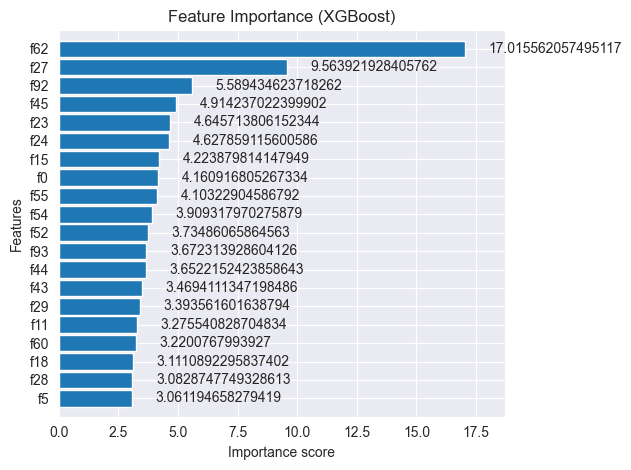

In [84]:
xgb.plot_importance(model_xgb, max_num_features=20, importance_type='gain', height=0.9)
plt.title("Feature Importance (XGBoost)")
plt.tight_layout()
plt.show()


In [85]:
import matplotlib.pyplot as plt

In [86]:
def show_feature_importance(df,filename, top_n = 40):
    top_feats = df.head(top_n)

    plt.figure(figsize=(10, 6))
    plt.barh(top_feats['feature'][::-1], top_feats['importance'][::-1])
    plt.xlabel('Importance Score')
    plt.title(f'Top {top_n} Feature Importances (XGBoost)')
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

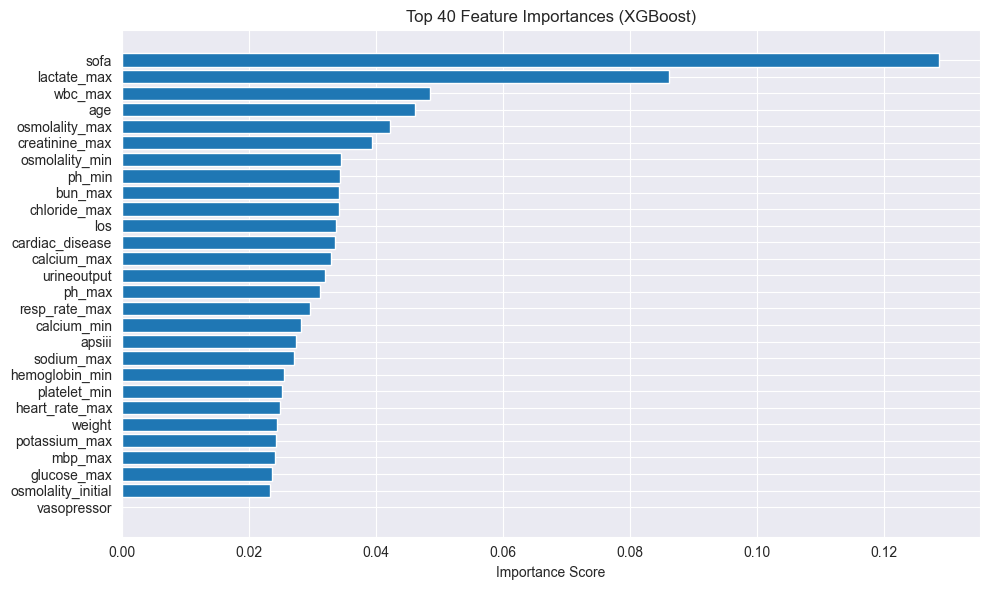

In [141]:
show_feature_importance(feat_imp_df,'replicateFeatureImportance.png')

In [88]:
# import seaborn as sns
#
# plt.figure(figsize=(10, 6))
# sns.barplot(x='importance', y='feature', data=top_feats)
# plt.title(f'Top {top_n} Feature Importances')
# plt.xlabel('Importance Score')
# plt.ylabel('Feature')
# plt.tight_layout()
# plt.show()

## XGBoost with top 40 features

In [89]:
top_features = feat_imp_df['feature'].head(40).tolist()
print("Top 40 Features Selected:")
print(top_features)

Top 40 Features Selected:
['sofa', 'lactate_max', 'race_UNKNOWN', 'bun_max', 'wbc_min', 'wbc_max', 'calcium_max', 'age', 'initial_heart_rate', 'bicarbonate_max', 'bicarbonate_initial', 'race_WHITE', 'bun_min', 'bun_initial', 'platelet_min', 'ph_min', 'urineoutput', 'creatinine_max', 'platelet_initial', 'diabetes_with_cc', 'glucose_min', 'bicarbonate_min', 'wbc_initial', 'cardiac_disease', 'lactate_min', 'osmolality_max', 'anion_gap_min', 'sodium_min', 'osmolality_initial', 'ph_initial', 'potassium_initial', 'weight', 'osmolality_min', 'potassium_min', 'anion_gap_initial', 'calcium_initial', 'hemoglobin_max', 'glucose_initial', 'sodium_initial', 'lactate_initial']


In [90]:
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

In [91]:
X_train_top_scaled, X_test_top_scaled = normalise_data(X_train_top, X_test_top)

In [92]:
model_xgb_top = train_xgboost(X_train_top_scaled, y_train)

In [93]:
model_xgb_top

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=False,
              eta=0.1, eval_metric='logloss', feature_types=None,
              feature_weights=None, gamma=0.25, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, ...)

In [94]:
evaluate_model(model_xgb_top, X_test_top_scaled, y_test )

Accuracy: 0.96
Sensitivity: 0.28
Specificity: 1.00
AUC: 0.93

With threshold 0.2:
Sensitivity: 0.44
Specificity: 0.98


               feature  importance
0                 sofa    0.106953
1          lactate_max    0.054098
19    diabetes_with_cc    0.048986
5              wbc_max    0.037755
11          race_WHITE    0.035679
7                  age    0.031892
3              bun_max    0.031596
4              wbc_min    0.028068
21     bicarbonate_min    0.027541
2         race_UNKNOWN    0.026972
24         lactate_min    0.026805
13         bun_initial    0.025646
20         glucose_min    0.024923
33       potassium_min    0.024332
15              ph_min    0.024144
8   initial_heart_rate    0.023673
9      bicarbonate_max    0.021475
16         urineoutput    0.021248
6          calcium_max    0.020644
39     lactate_initial    0.020571


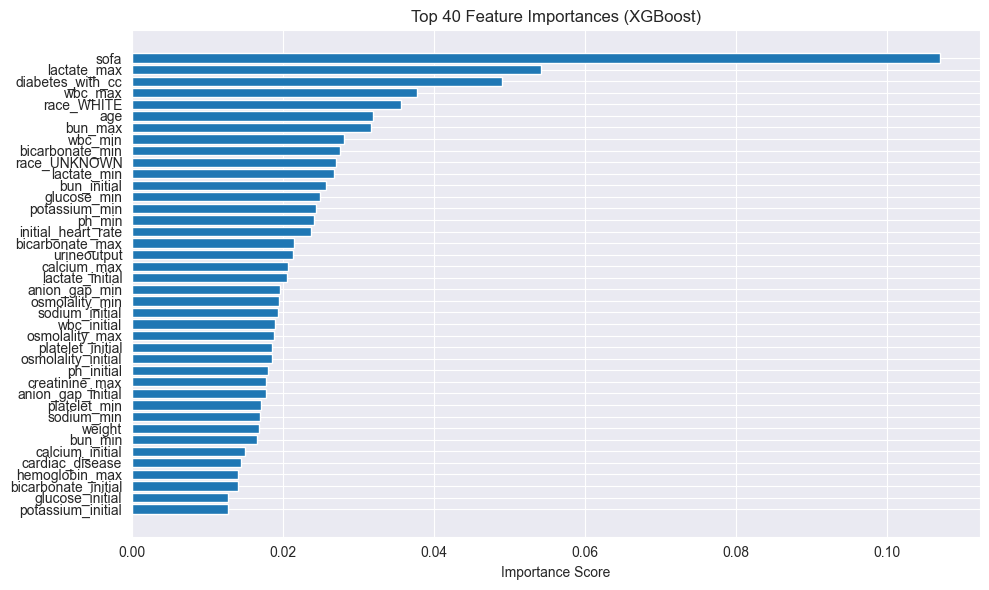

In [95]:
# Get feature importance
imp_top = model_xgb_top.feature_importances_
feat_imp_top = get_feature_imp_df(imp_top, top_features)
show_feature_importance(feat_imp_top,'preTopFeatureImportance.png')

# SHAP

In [56]:
import numpy as np
import shap

In [96]:
tree_explainer = shap.TreeExplainer(model_xgb_top)
shap_values = tree_explainer.shap_values(X_train_top_scaled)

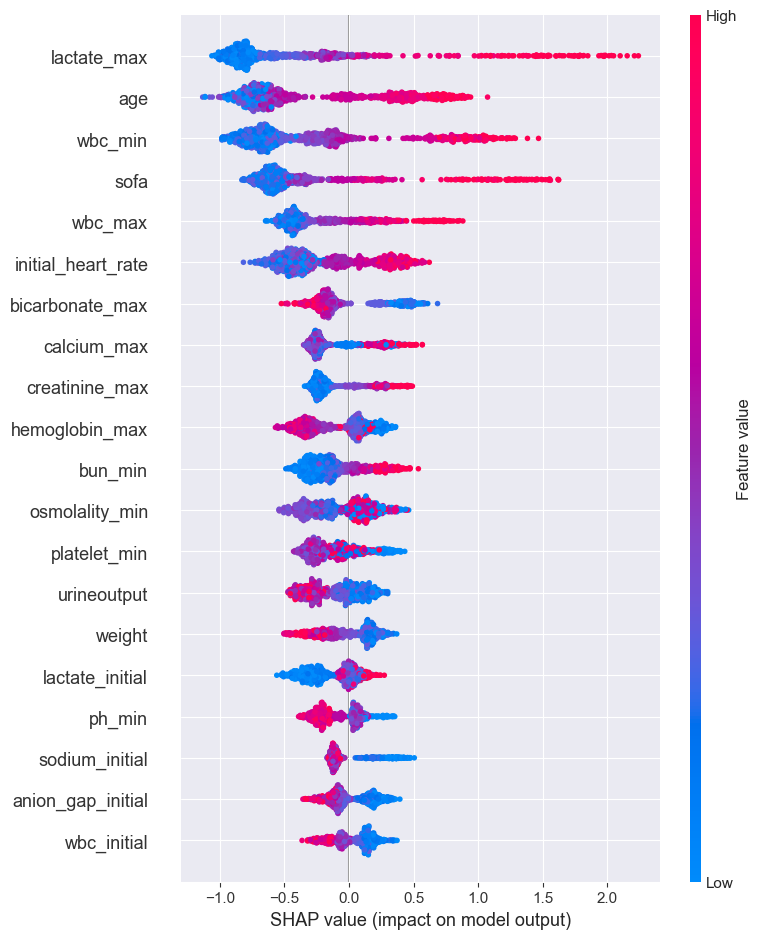

In [97]:
shap.summary_plot(shap_values, X_train_top_scaled, feature_names=top_features)

In [98]:
# Explain model
explainer = shap.Explainer(model_xgb_top)
shap_values = explainer(X_train_top)

In [99]:
np.shape(shap_values.values)

(1099, 40)

## Waterfall plot

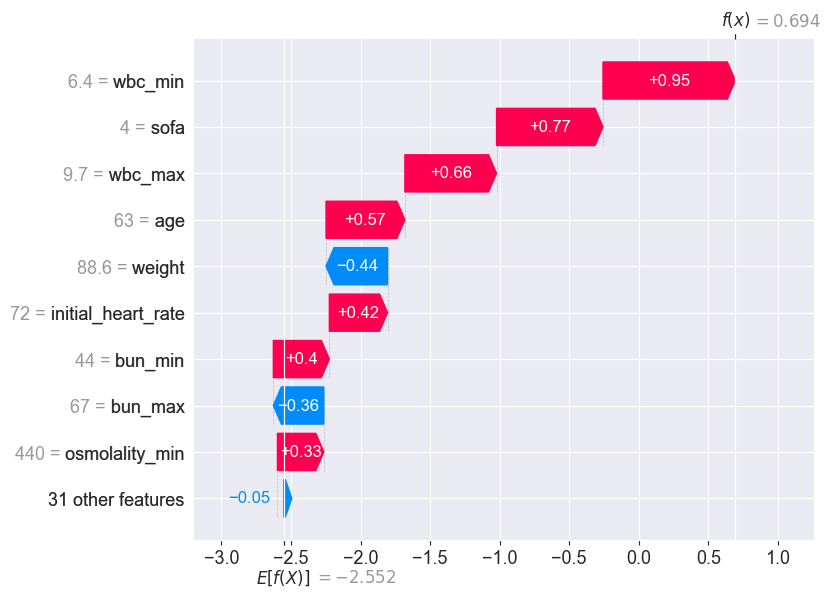

In [100]:
# for the 1st observation
shap.plots.waterfall(shap_values[0])

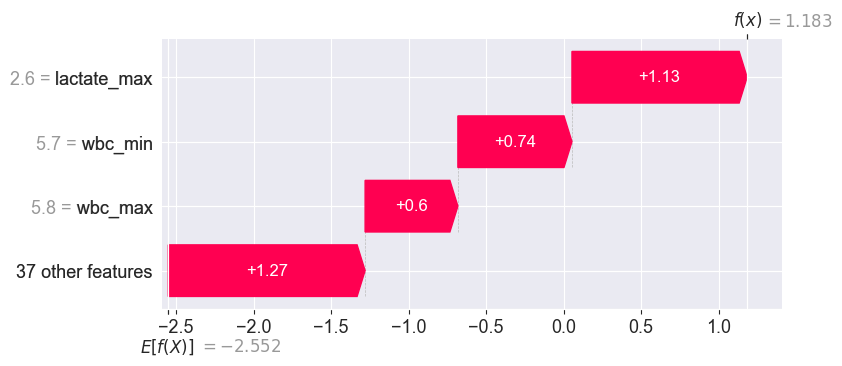

In [101]:
shap.plots.waterfall(shap_values[1], max_display=4)

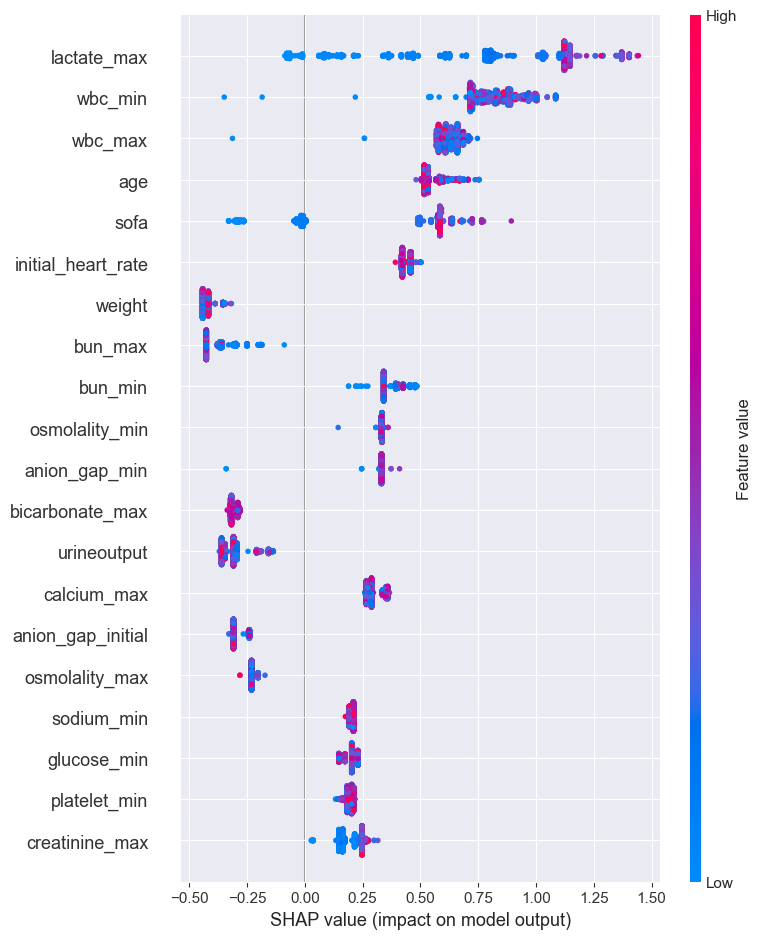

In [102]:
shap.summary_plot(shap_values, X_train_top, plot_type="dot")

In [86]:
## Force plot

In [139]:
shap.plots.force(shap_values[0])
shap.plots.force(shap_values[0:100]) 

## Absolute Mean SHAP
Which features are more important to the model.

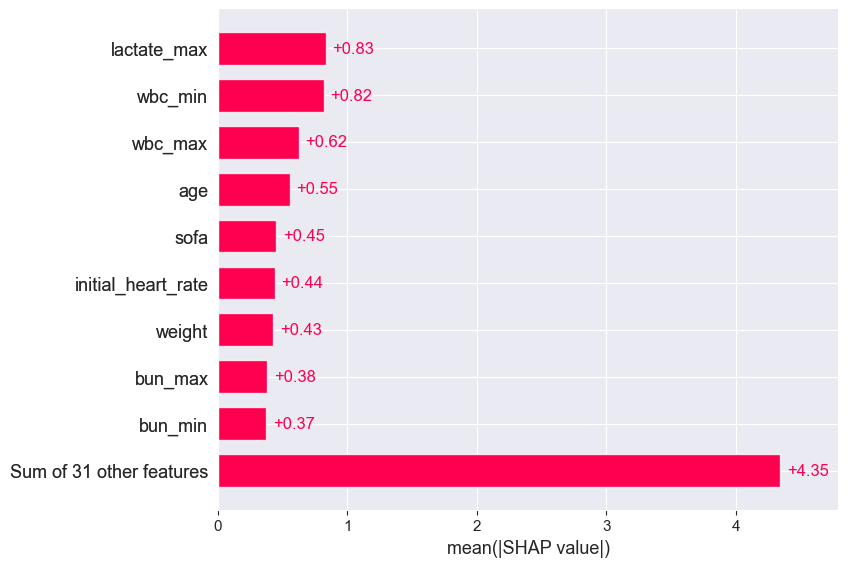

In [103]:
shap.plots.bar(shap_values)

## Beeswarm plot
All of the shap values.

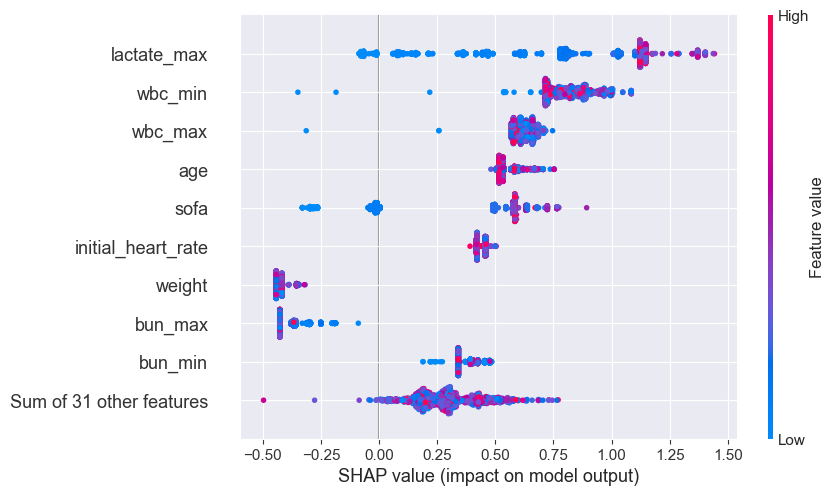

In [104]:
shap.plots.beeswarm(shap_values)

## Dependence plots

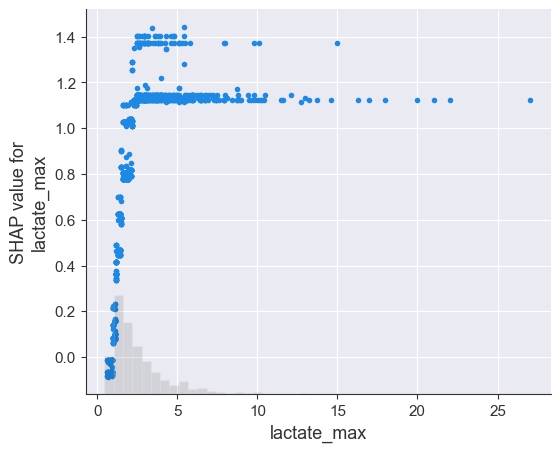

In [105]:
shap.plots.scatter(shap_values[:, 'lactate_max'])

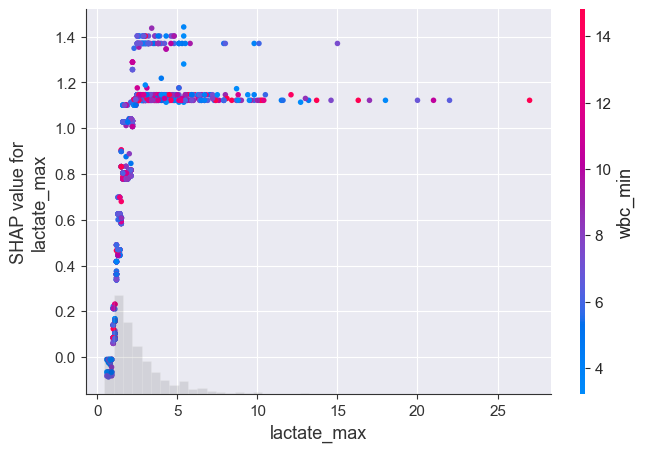

In [106]:
shap.plots.scatter(shap_values[:, 'lactate_max'], color=shap_values[:, 'wbc_min'])

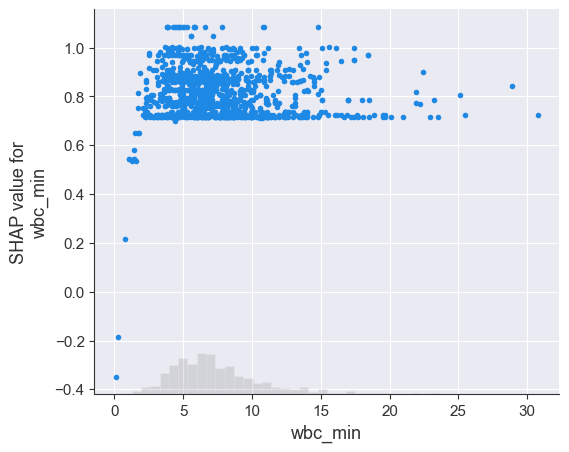

In [107]:
shap.plots.scatter(shap_values[:, 'wbc_min'])

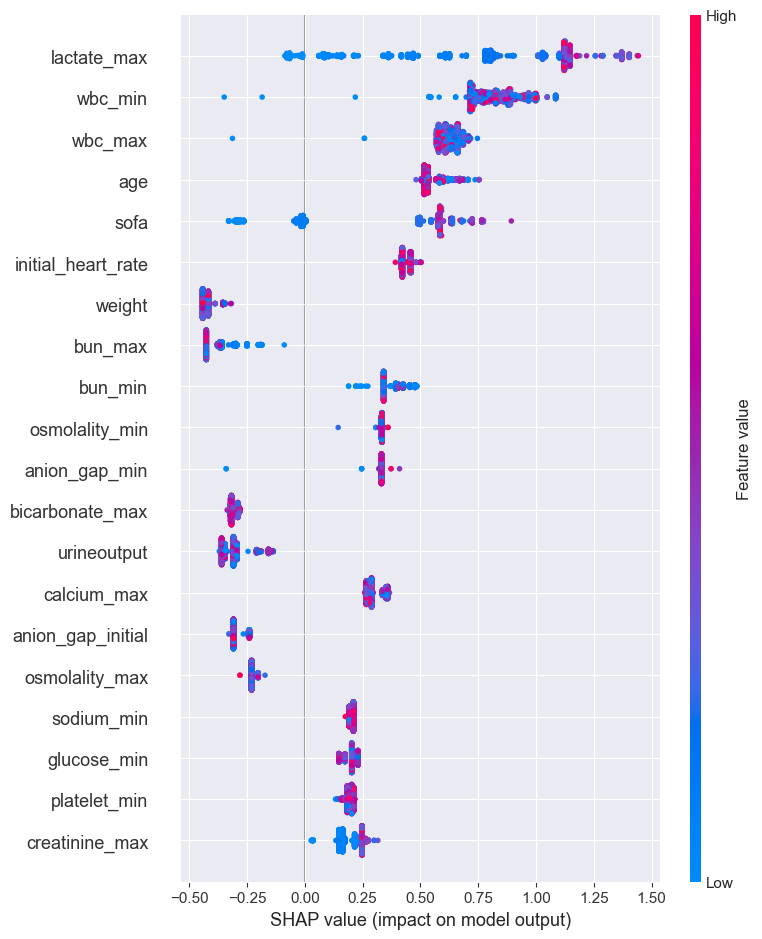

In [108]:
shap.summary_plot(shap_values, X_train_top)

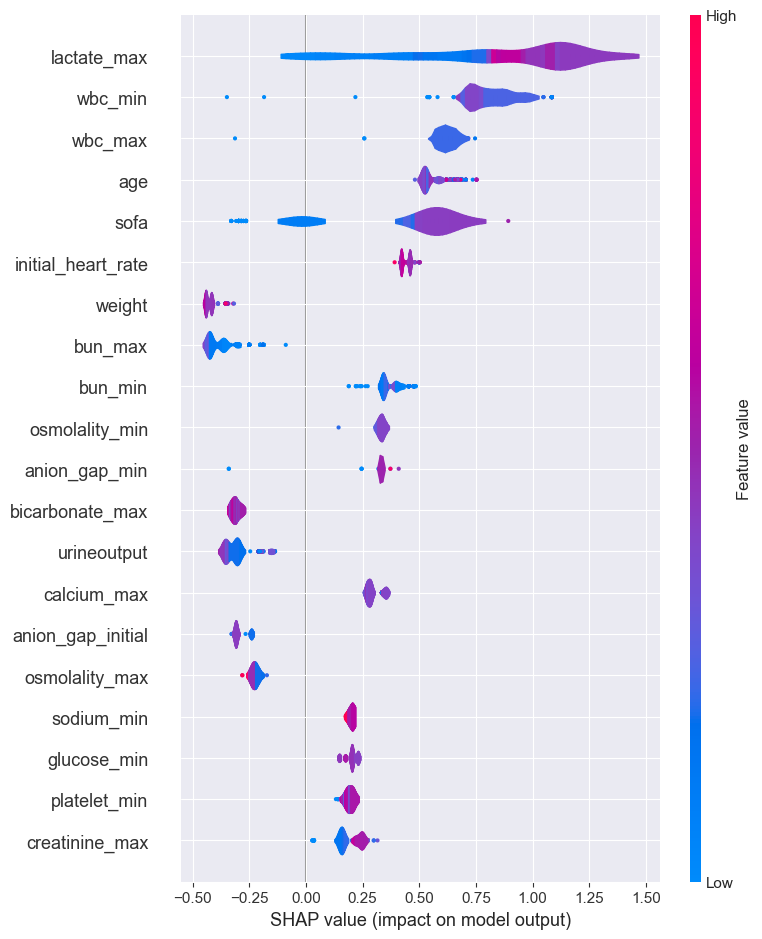

In [109]:
shap.summary_plot(shap_values, X_train_top, plot_type="violin", feature_names=X_train_top.columns)

Feature Interaction Detection with SHAP: Revealing Complex Dependencies Between Variables: https://medium.com/@lfoster49203/feature-interaction-detection-with-shap-revealing-complex-dependencies-between-variables-ecab7ff4dbc2

# LIME

In [110]:
from lime.lime_tabular import LimeTabularExplainer
explainer = LimeTabularExplainer(
    training_data=X_train.values,  # Use normalized data for explanation
    feature_names=X_train.columns,
    mode='classification',
    class_names=['0', '1'],  # Adjust based on your target
    discretize_continuous=False,  # Disable discretization to test
    feature_selection='auto',
    random_state=42
)

# Select an instance to explain
instance_idx = 0  # Adjust to your desired instance
instance = X_train.iloc[instance_idx].values  # Use normalized instance

# Get LIME explanation
exp = explainer.explain_instance(
    data_row=instance,
    predict_fn=lambda x: model_xgb.predict_proba(X_train_normalized.iloc[x.index].values if isinstance(x, pd.Series) else x),  # Adjust predict_fn
    num_features=min(10, len(X_train.columns))
)

# Visualize the explanation
exp.show_in_notebook()  # For Jupyter notebook
exp.as_pyplot_figure()
plt.title(f"LIME Explanation for Instance {instance_idx}")
plt.tight_layout()
plt.show()

# Print data info
print("X_train shape:", X_train.shape)
print("X_train dtypes:\n", X_train.dtypes)
print("X_train sample:\n", X_train.head())

ImportError: cannot import name 'display' from 'IPython.core.display' (C:\Users\maria\Code\master\dp_cgans\dp_cgans_env\Lib\site-packages\IPython\core\display.py)